In [1]:
# =====================================================
# SUPPLY CHAIN INTELLIGENCE SYSTEM
# END-TO-END PIPELINE
# =====================================================

# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries loaded ✅")




Libraries loaded ✅


In [2]:
# ================================
# 2. LOAD DATA
# ================================
file_path = r"C:\Users\Deepak khadka\Desktop\DA_JOB_HU2\supply-chain-intelligence\data\raw\supply_chain_data.csv"

df = pd.read_csv(file_path)

print("Data loaded ✅")




Data loaded ✅


In [ ]:
# ================================
# 3. COLUMN NAMES
# ================================
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

print("\nColumns:")
print(df.columns)





Columns:
Index(['product_type', 'sku', 'price', 'availability',
       'number_of_products_sold', 'revenue_generated', 'customer_demographics',
       'stock_levels', 'lead_times', 'order_quantities', 'shipping_times',
       'shipping_carriers', 'shipping_costs', 'supplier_name', 'location',
       'lead_time', 'production_volumes', 'manufacturing_lead_time',
       'manufacturing_costs', 'inspection_results', 'defect_rates',
       'transportation_modes', 'routes', 'costs'],
      dtype='object')


In [4]:
# ================================
# 4. HANDLE MISSING VALUES
# ================================
df = df.dropna()

print("\nMissing values handled ✅")





Missing values handled ✅


In [5]:
# ================================
# 5. FEATURE ENGINEERING 
# ================================

# Profit metrics
df['profit'] = df['revenue_generated'] - df['costs']
df['profit_margin'] = df['profit'] / df['revenue_generated']
df['cost_ratio'] = df['costs'] / df['revenue_generated']

# Inventory Risk (using stock_levels & sales as proxy)
df['inventory_risk'] = np.where(
    df['stock_levels'] < df['number_of_products_sold'], 'High',
    np.where(df['stock_levels'] < df['number_of_products_sold'] * 1.2, 'Medium', 'Low')
)

# Supplier Risk (based on defect rates)
df['supplier_risk'] = np.where(
    df['defect_rates'] > 0.05, 'High',
    np.where(df['defect_rates'] > 0.02, 'Medium', 'Low')
)

# Shipping Cost Ratio
df['shipping_cost_ratio'] = df['shipping_costs'] / df['revenue_generated']

print("\nFeature engineering done ✅")





Feature engineering done ✅


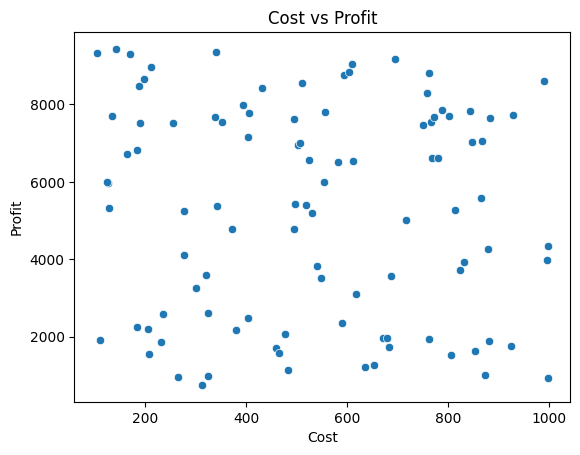


Top Suppliers by Revenue:
  supplier_name  revenue_generated  defect_rates
0    Supplier 1      157528.995039      1.803630
1    Supplier 2      125467.418605      2.362750
4    Supplier 5      110343.463656      2.665408
2    Supplier 3       97795.979638      2.465786
3    Supplier 4       86468.961799      2.337397


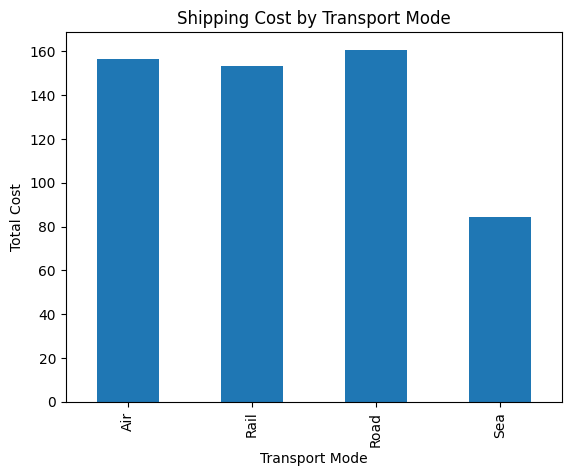

In [6]:
# ================================
# 6. BUSINESS ANALYSIS
# ================================

# --- Profit vs Cost ---
plt.figure()
sns.scatterplot(x=df['costs'], y=df['profit'])
plt.title("Cost vs Profit")
plt.xlabel("Cost")
plt.ylabel("Profit")
plt.show()


# --- Top Suppliers ---
supplier_analysis = df.groupby('supplier_name').agg({
    'revenue_generated': 'sum',
    'defect_rates': 'mean'
}).reset_index()

print("\nTop Suppliers by Revenue:")
print(supplier_analysis.sort_values(by='revenue_generated', ascending=False).head())


# --- Transport Cost ---
transport_cost = df.groupby('transportation_modes')['shipping_costs'].sum()

plt.figure()
transport_cost.plot(kind='bar')
plt.title("Shipping Cost by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Total Cost")
plt.show()




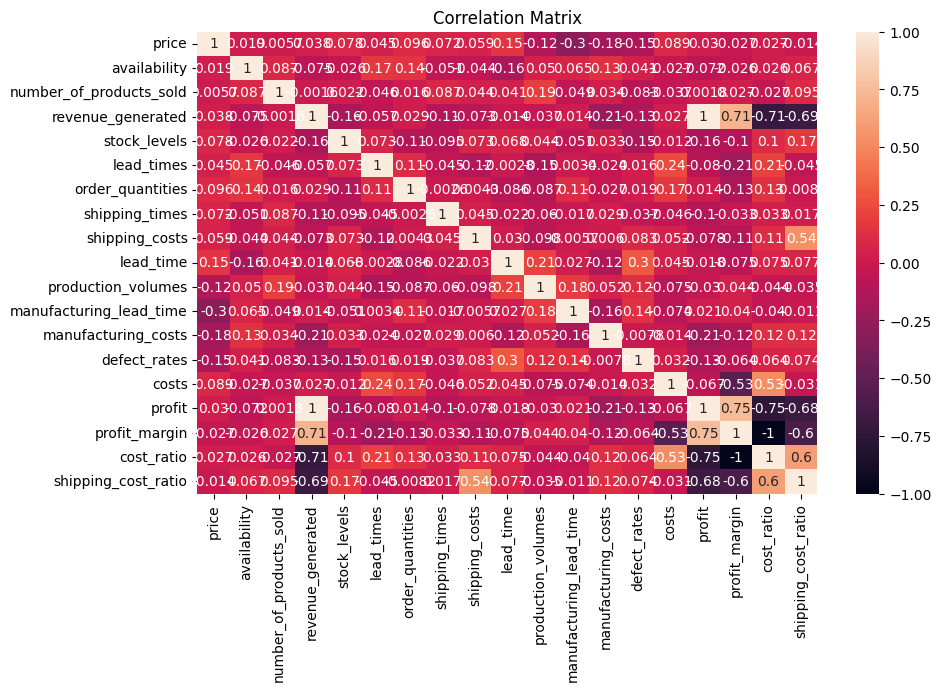

In [7]:
# ================================
# 7. CORRELATION 
# ================================
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()




In [8]:
# ================================
# 8. SAVE CLEANED DATA
# ================================
output_path = r"C:\Users\Deepak khadka\Desktop\DA_JOB_HU2\supply-chain-intelligence\data\processed\cleaned_supply_chain.csv"

df.to_csv(output_path, index=False)

print("\nProcessed dataset saved ✅")





Processed dataset saved ✅


In [9]:
# ================================
# 9. FINAL BUSINESS INSIGHTS
# ================================
print("\n========== KEY INSIGHTS ==========")

print("\n1. Profitability:")
print("Profit depends heavily on cost control → high cost reduces margins")

print("\n2. Supplier Risk:")
print(df['supplier_risk'].value_counts())

print("\n3. Inventory Risk:")
print(df['inventory_risk'].value_counts())

print("\n4. Logistics:")
print("Transport modes contribute unevenly to cost → optimization opportunity")

print("\nPROJECT COMPLETED SUCCESSFULLY ✅")



========== KEY INSIGHTS ==========

1. Profitability:
Profit depends heavily on cost control → high cost reduces margins

2. Supplier Risk:
supplier_risk
High      97
Medium     2
Low        1
Name: count, dtype: int64

3. Inventory Risk:
inventory_risk
High      98
Low        1
Medium     1
Name: count, dtype: int64

4. Logistics:
Transport modes contribute unevenly to cost → optimization opportunity

PROJECT COMPLETED SUCCESSFULLY ✅
